[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/heitorramos/icd/blob/main/exemplos/08-estimadores/notebook-colab.ipynb)


In [ ]:
# Preparação automática para execução no Google Colab.
# Fora do Colab, esta célula não altera o diretório de trabalho.
try:
    import google.colab  # type: ignore
except ImportError:
    pass
else:
    import os
    import subprocess
    from pathlib import Path

    repository = Path("/content/icd")
    if not repository.exists():
        subprocess.run([
            "git", "clone", "--depth", "1",
            "https://github.com/heitorramos/icd.git", str(repository)
        ], check=True)
    os.chdir(repository / "exemplos/08-estimadores")
    print("Material preparado em:", Path.cwd())


# Estimadores com Palmer Penguins

Notebook das Aulas 08 e 09

# Objetivos

Este notebook usa a base **Palmer Penguins** para transformar população,
amostra, estimador, viés e variância em objetos que podemos simular.

Ao final, você deve conseguir:

- distinguir parâmetro, estimador e estimativa;
- construir uma distribuição amostral por simulação;
- estimar viés, variância, erro padrão e risco;
- explicar o efeito do tamanho da amostra;
- comparar média, mediana e média aparada sob diferentes perdas.

## Como estudar este capítulo

As Aulas 08 e 09 respondem a duas perguntas complementares. Primeiro:
**como uma estatística calculada em uma amostra se comporta se
repetirmos a amostragem?** Depois: **como escolher entre estimadores que
cometem erros de maneiras diferentes?** A distribuição amostral liga
essas duas perguntas.

Começaremos distinguindo parâmetro, estimador e estimativa. A simulação
transforma o estimador em uma variável: extraímos muitas amostras,
calculamos uma estimativa em cada uma e observamos sua distribuição. O
centro revela viés; a dispersão revela variabilidade; a perda traduz o
custo de cada erro; e o risco combina esses elementos em um desempenho
médio.

A base completa será tratada como uma população didática. Isso permite
conhecer o parâmetro verdadeiro e verificar os estimadores, algo que
normalmente não é possível em um estudo real. Ao ler os resultados,
separe sempre o que ocorre nesta população construída do princípio
estatístico que a simulação pretende ilustrar.

### Transição da Aula 08 para a Aula 09

A Aula 08 concentra-se em amostragem, distribuição amostral, viés,
variância e erro padrão. A Aula 09 parte desses objetos para comparar
estimadores sob funções de perda, robustez e risco. O segundo assunto
depende do primeiro: não existe “melhor estimador” sem especificar o
processo de dados e o tipo de erro que queremos evitar.

# 1. Download da base

O dataset está disponível no Kaggle sob licença CC0. Em um ambiente
novo, instale `kagglehub`, `pandas`, `numpy`, `matplotlib`, `seaborn` e
`scipy`.

In [ ]:
import kagglehub

path = kagglehub.dataset_download(
    "parulpandey/palmer-archipelago-antarctica-penguin-data"
)
print(path)

# 2. Preparação

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import trim_mean

sns.set_theme(style="whitegrid", context="notebook")
rng = np.random.default_rng(20260824)

csv_files = sorted(Path(path).rglob("penguins_size.csv"))
if not csv_files:
    csv_files = sorted(Path(path).rglob("*.csv"))

penguins = pd.read_csv(csv_files[0])
penguins = penguins.rename(columns={
    "culmen_length_mm": "bill_length_mm",
    "culmen_depth_mm": "bill_depth_mm",
})
penguins = penguins.dropna(subset=["body_mass_g", "species", "island"])
penguins.head()

# 3. Conhecendo a população didática

Nesta atividade, trataremos todos os registros válidos como uma
população conhecida. Isso permite comparar cada estimativa com o valor
real.

In [ ]:
massas = penguins["body_mass_g"].to_numpy()
mu = massas.mean()
sigma = massas.std(ddof=0)

print(f"N = {len(massas)}")
print(f"Média populacional: {mu:.1f} g")
print(f"Desvio padrão populacional: {sigma:.1f} g")
penguins.groupby("species")["body_mass_g"].agg(["count", "mean", "std"])

> **Interpretação**
>
> Separe parâmetro, estimador e estimativa observada. A qualidade do
> estimador deve ser avaliada em amostras repetidas por viés, variância
> e erro quadrático, não por um único resultado favorável.

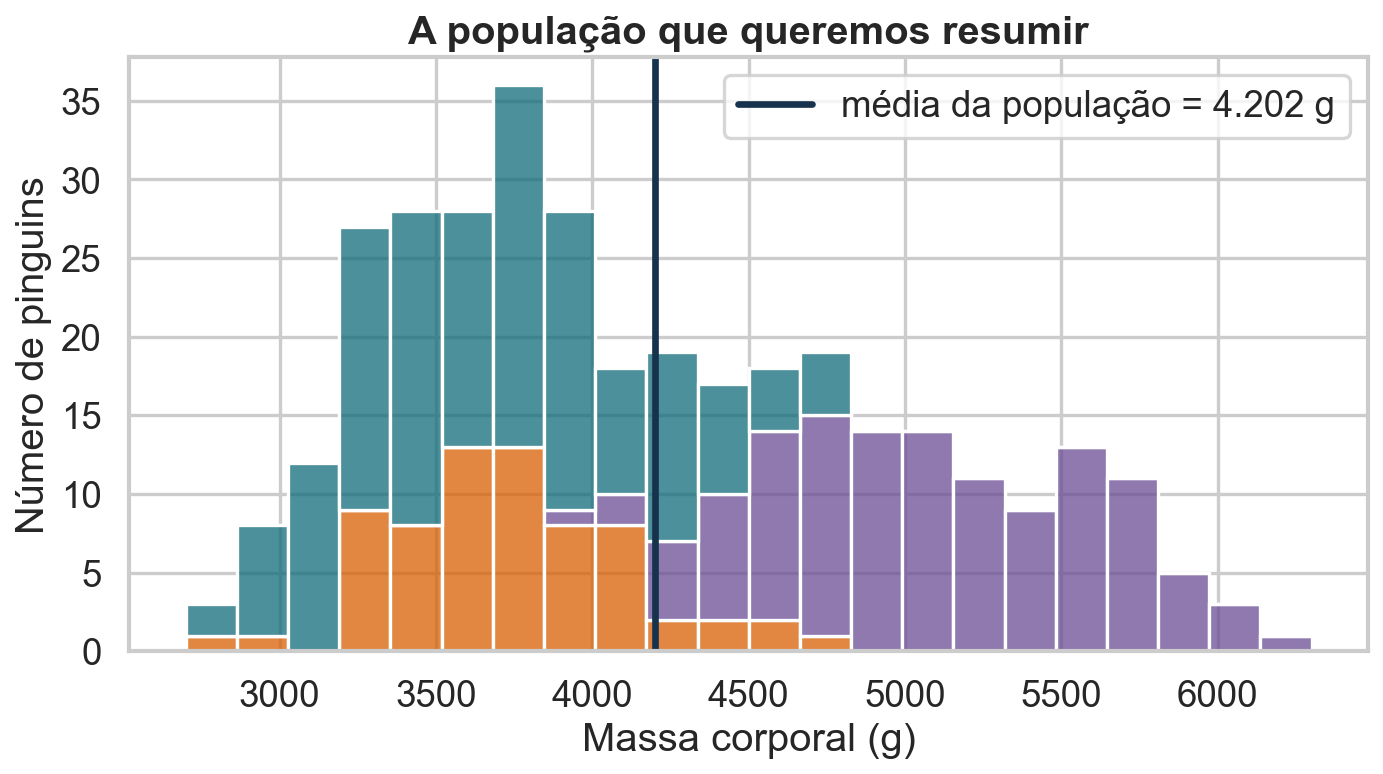

## Variância populacional e amostral

Como estamos tratando os registros completos como população didática,
usamos `ddof=0` e dividimos por $N$. Quando uma amostra é usada para
estimar a variância de uma população, usamos $n-1$:

$$
\sigma^2=\frac{1}{N}\sum_{i=1}^{N}(x_i-\mu)^2,
\qquad
s^2=\frac{1}{n-1}\sum_{i=1}^{n}(x_i-\bar x)^2.
$$

Há duas justificativas complementares. Os desvios em torno de $\bar x$
somam zero, deixando apenas $n-1$ graus de liberdade. Além disso:

$$
\mathbb E\!\left[\sum_{i=1}^{n}(X_i-\bar X)^2\right]=(n-1)\sigma^2,
$$

portanto dividir por $n-1$ remove o viés para baixo.

In [ ]:
amostra_variancia = rng.choice(massas, size=20, replace=False)
print("Dividindo por n:   ", amostra_variancia.var(ddof=0))
print("Dividindo por n-1: ", amostra_variancia.var(ddof=1))

> **Interpretação**
>
> A variância com divisor n descreve o conjunto observado. Quando a
> média populacional é estimada pela média amostral, perde-se um grau de
> liberdade e o divisor n−1 corrige o viés para baixo.

# 4. Uma amostra, uma estimativa

In [ ]:
amostra = rng.choice(massas, size=20, replace=False)
x_barra = amostra.mean()

print(f"Parâmetro μ: {mu:.1f} g")
print(f"Estimativa x̄: {x_barra:.1f} g")
print(f"Erro observado: {x_barra - mu:.1f} g")

Execute a célula novamente com outra semente. A estimativa muda porque a
amostra muda; o parâmetro permanece fixo.

> **Interpretação**
>
> O erro exibido pertence a uma amostra particular: ele pode ser
> positivo ou negativo e muda quando repetimos a seleção. Essa
> variabilidade não transforma o parâmetro em algo aleatório; ela
> descreve a incerteza do procedimento amostral.

# 5. Distribuição amostral

In [ ]:
def simular_medias(valores, n, repeticoes=5000):
    return np.array([
        rng.choice(valores, size=n, replace=True).mean()
        for _ in range(repeticoes)
    ])

medias_30 = simular_medias(massas, n=30)

sns.histplot(medias_30, bins=30)
plt.axvline(mu, color="darkorange", linewidth=3)
plt.xlabel("Média amostral (g)")
plt.show()

In [ ]:
vies = medias_30.mean() - mu
variancia = medias_30.var(ddof=1)
erro_padrao = medias_30.std(ddof=1)

print(f"Viés estimado: {vies:.1f} g")
print(f"Variância estimada: {variancia:.1f} g²")
print(f"Erro padrão estimado: {erro_padrao:.1f} g")

> **Interpretação**
>
> O centro das médias simuladas deve ficar próximo de $\mu$, sinal de
> pouco viés. Já o desvio padrão dessas médias é o erro padrão: ele mede
> quanto a estimativa mudaria entre amostras do mesmo tamanho.

## 5.1 Proporções: Binomial ou Hipergeométrica?

Para estudar a proporção de pinguins Gentoo, defina $Y_i=1$ quando o
indivíduo selecionado é Gentoo e $Y_i=0$ caso contrário. Cada observação
isolada tem distribuição Bernoulli. A distribuição da soma

$$
K=\sum_{i=1}^{n}Y_i
$$

depende, porém, do desenho amostral. Se os $Y_i$ forem independentes e
tiverem a mesma probabilidade $p$, então
$K\sim\operatorname{Binomial}(n,p)$. Isso ocorre em amostragem com
reposição ou quando pensamos em observações independentes de um processo
gerador.

Se retirarmos $n$ indivíduos **sem reposição** de uma população finita
com $N$ indivíduos e $M$ Gentoo, a distribuição exata será

$$
K\sim\operatorname{Hipergeométrica}(N,M,n),
\qquad
P(K=k)=\frac{\binom{M}{k}\binom{N-M}{n-k}}{\binom{N}{n}}.
$$

A diferença aparece porque, sem reposição, cada seleção altera a
composição da população restante. A média é a mesma nos dois modelos,
$E[K]=np$, mas a variância hipergeométrica contém a **correção para
população finita**:

$$
\operatorname{Var}(K)
=np(1-p)\frac{N-n}{N-1}.
$$

In [ ]:
especies = penguins["species"].to_numpy()
N = len(especies)
M = np.sum(especies == "Gentoo")
n = 40
p = M / N
repeticoes = 5000

sem_reposicao = np.array([
    np.sum(rng.choice(especies, size=n, replace=False) == "Gentoo")
    for _ in range(repeticoes)
])
com_reposicao = np.array([
    np.sum(rng.choice(especies, size=n, replace=True) == "Gentoo")
    for _ in range(repeticoes)
])

pd.DataFrame({
    "modelo": ["sem reposição", "com reposição"],
    "média simulada": [sem_reposicao.mean(), com_reposicao.mean()],
    "variância simulada": [sem_reposicao.var(ddof=1), com_reposicao.var(ddof=1)],
    "variância teórica": [
        n * p * (1 - p) * (N - n) / (N - 1),
        n * p * (1 - p),
    ],
}).round(3)

> **Interpretação**
>
> As duas contagens têm praticamente a mesma média. Sem reposição,
> contudo, a variabilidade é menor: a correção $(N-n)/(N-1)$ registra a
> dependência entre as seleções. Quando $N$ é muito grande em relação a
> $n$, essa correção fica próxima de 1 e a Binomial se torna uma boa
> aproximação da Hipergeométrica.

# 6. Tamanho da amostra

In [ ]:
for n in [10, 30, 80]:
    estimativas = simular_medias(massas, n=n)
    sns.kdeplot(estimativas, label=f"n = {n}")

plt.axvline(mu, color="black", linestyle="--")
plt.xlabel("Média amostral (g)")
plt.legend()
plt.show()

Compare o erro padrão empírico com a fórmula:

In [ ]:
for n in [10, 30, 80]:
    empirico = simular_medias(massas, n=n).std(ddof=1)
    teorico = sigma / np.sqrt(n)
    print(f"n={n:>2}: empírico={empirico:6.1f} | σ/√n={teorico:6.1f}")

> **Interpretação**
>
> Ao aumentar $n$, as distribuições ficam mais estreitas sem mudar
> substancialmente de centro. A proximidade entre os valores empíricos e
> $\sigma/\sqrt n$ confirma a queda do erro padrão na razão inversa da
> raiz do tamanho amostral.

# 7. Uma amostra maior pode continuar enviesada

Agora selecionaremos apenas pinguins Gentoo, embora o parâmetro ainda
seja a média de todas as espécies.

In [ ]:
massas_gentoo = penguins.loc[
    penguins["species"] == "Gentoo", "body_mass_g"
].to_numpy()

aleatorias = simular_medias(massas, n=30)
enviesadas = simular_medias(massas_gentoo, n=30)

print(f"Centro das amostras aleatórias: {aleatorias.mean():.1f} g")
print(f"Centro das amostras Gentoo: {enviesadas.mean():.1f} g")
print(f"Parâmetro de interesse: {mu:.1f} g")

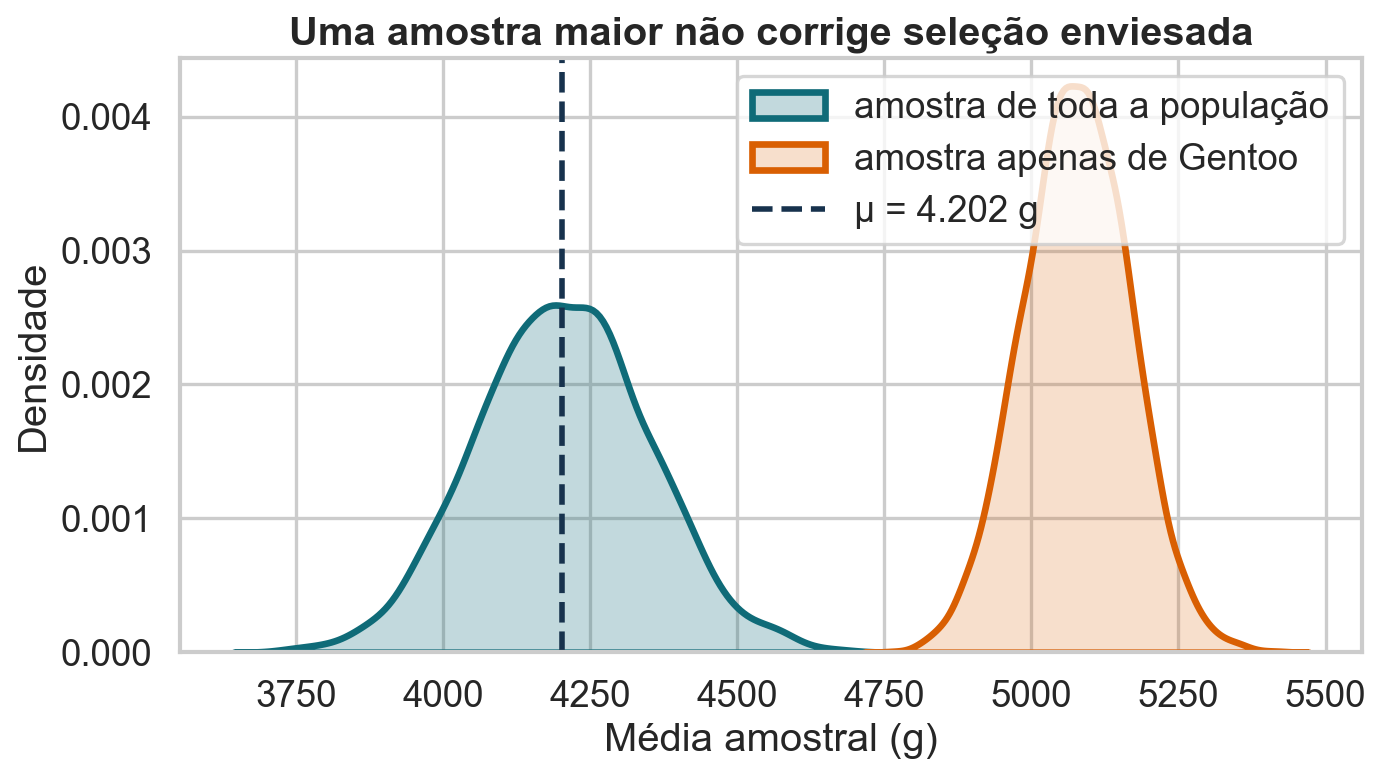

> **Interpretação**
>
> A distribuição obtida apenas com Gentoo pode ser estreita e, ainda
> assim, ficar sistematicamente afastada do parâmetro de todas as
> espécies. Mais observações reduzem variância; não corrigem uma regra
> de seleção que representa a população errada.

# 8. Funções de perda

In [ ]:
dados = np.array([3100, 3300, 3500, 3700, 3900, 4200, 6100])

def perda_quadratica(theta, valores):
    return np.mean((theta - valores) ** 2)

def perda_absoluta(theta, valores):
    return np.mean(np.abs(theta - valores))

print(f"Média: {dados.mean():.1f} g")
print(f"Mediana: {np.median(dados):.1f} g")

Para a perda quadrática,

$$
\frac{d}{d\theta}\frac1n\sum_i(\theta-x_i)^2
=\frac2n\left(n\theta-\sum_i x_i\right).
$$

Igualar a derivada a zero fornece $\theta=\bar x$; a segunda derivada é
$2>0$, confirmando o mínimo. Para a perda absoluta, a inclinação é
negativa quando há mais observações à direita e positiva quando há mais
à esquerda. Ela cruza zero nas medianas.

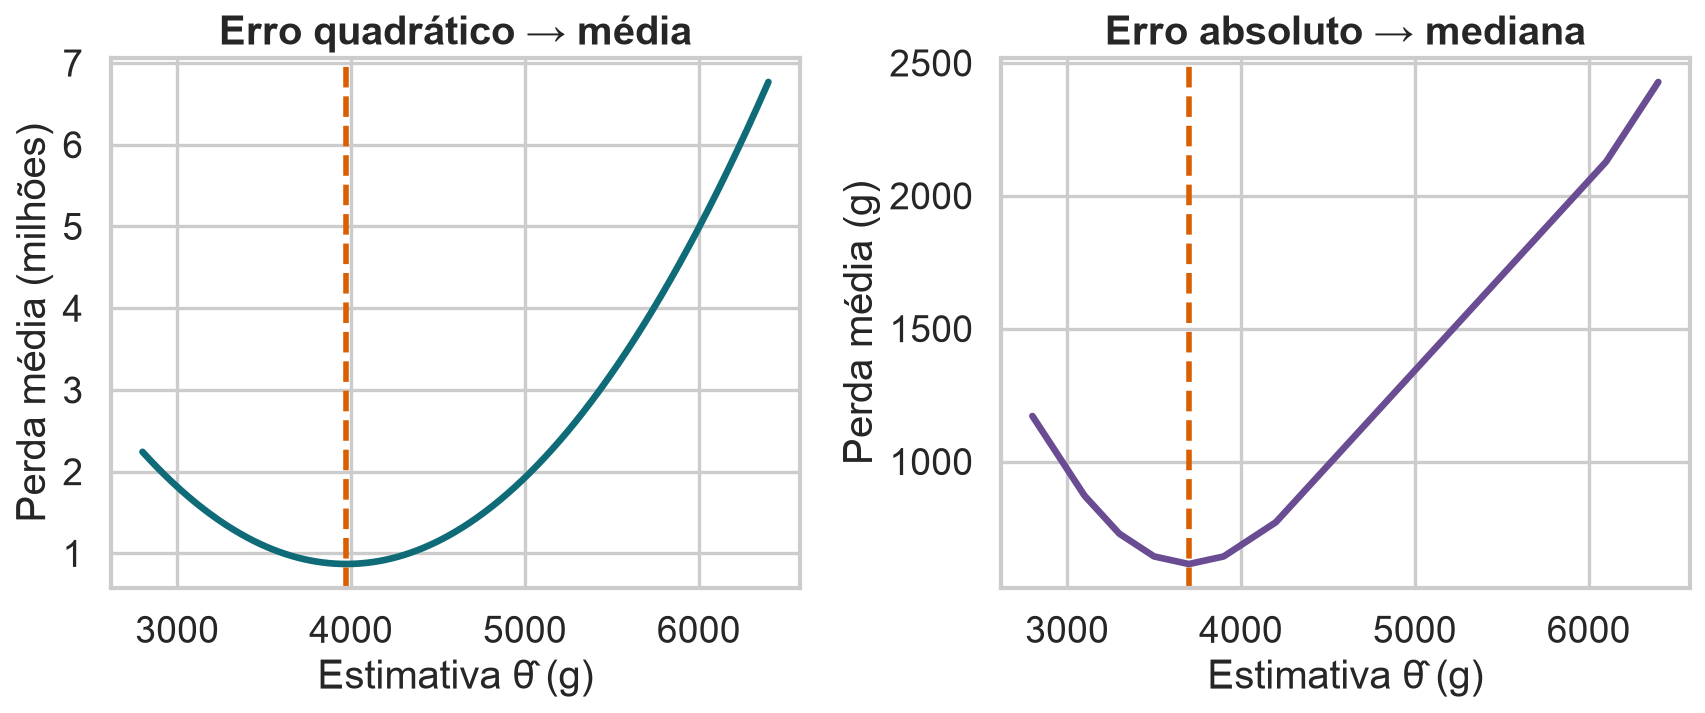

> **Interpretação**
>
> A perda quadrática cresce rapidamente com erros grandes e atinge o
> mínimo na média. A perda absoluta cresce linearmente e é minimizada
> pela mediana; por isso, ela é menos dominada pelo valor extremo de
> 6.100 g.

## 8.1 Quando a direção do erro também importa

As perdas anteriores são **simétricas**: errar duas unidades para baixo
ou para cima produz o mesmo custo. Isso nem sempre representa o problema
real. Se $a$ é a estimativa e $x$ é o valor real, definimos o erro por

$$
e=a-x.
$$

Assim, $e<0$ significa **subestimação**, $e>0$ significa
**superestimação** e $e=0$ significa acerto. Suponha que uma
subestimação custe três vezes mais que uma superestimação de mesma
magnitude. Uma perda possível é

$$
L(e)=
\begin{cases}
3e^2, & e<0,\\
e^2, & e\geq 0.
\end{cases}
$$

Por exemplo, $L(-2)=12$, enquanto $L(2)=4$. A magnitude do erro é a
mesma, mas sua consequência não é.

Considere agora os três valores $1$, $2$ e $3$. Sob perda quadrática
simétrica, o centro ótimo é a média, $a^*=2$. Com a perda assimétrica
acima, um candidato entre $2$ e $3$ superestima os valores $1$ e $2$,
mas subestima o valor $3$. Portanto, sua perda total é

$$
R(a)=(a-1)^2+(a-2)^2+3(a-3)^2,
\qquad 2<a<3,
$$

em que $R(a)$ é o risco empírico, isto é, a soma das perdas nos três
valores. Derivando em relação à estimativa $a$,

$$
\begin{aligned}
R'(a)
&=2(a-1)+2(a-2)+6(a-3)\\
&=10a-24.
\end{aligned}
$$

Igualando a derivada a zero,

$$
10a-24=0
\quad\Longrightarrow\quad
a^*=2{,}4.
$$

O resultado está de fato no intervalo usado na derivação, $2<a<3$. A
solução se desloca acima da média porque estimativas baixas ficam mais
expostas ao erro que recebeu peso três. O procedimento aceita alguma
superestimação adicional para reduzir subestimações mais caras.

> **Interpretação**
>
> A melhor estimativa não depende apenas dos dados. Ela depende também
> da função de perda, que traduz as consequências de cada decisão. Sob
> perda quadrática assimétrica, o ótimo é chamado de **expectil**; a
> média é o caso simétrico.

# 9. Comparando estimadores pelo risco

In [ ]:
def calcular_estimativas(valores, n=20, repeticoes=5000):
    amostras = rng.choice(valores, size=(repeticoes, n), replace=True)
    return {
        "média": amostras.mean(axis=1),
        "mediana": np.median(amostras, axis=1),
        "média aparada 10%": np.array([
            trim_mean(amostra, proportiontocut=0.10)
            for amostra in amostras
        ]),
    }

estimadores = calcular_estimativas(massas)

resultados = []
for nome, valores in estimadores.items():
    vies = valores.mean() - mu
    variancia = valores.var(ddof=0)
    mse = np.mean((valores - mu) ** 2)
    mae = np.mean(np.abs(valores - mu))
    resultados.append({
        "estimador": nome,
        "viés": vies,
        "variância": variancia,
        "MSE": mse,
        "MAE": mae,
        "viés² + variância": vies ** 2 + variancia,
    })

pd.DataFrame(resultados)

> **Interpretação**
>
> O MSE combina viés e variância:
> $\operatorname{MSE}=\operatorname{viés}^2+\operatorname{variância}$.
> Assim, o melhor estimador depende da distribuição e da perda adotada;
> robustez pode compensar uma pequena perda de eficiência quando há
> caudas ou valores extremos.

# 10. Investigue

1.  Troque `n=20` por `n=10`, `n=50` e `n=100`. O que muda?
2.  Restrinja a população a uma única espécie. Qual estimador tem menor
    MSE?
3.  Adicione valores extremos a 5% das amostras. A média continua
    vencendo?
4.  Compare o resultado usando perda absoluta em vez de quadrática.
5.  Explique por que aumentar $n$ reduz variância, mas não corrige
    seleção enviesada.

# Fonte

Gorman, K. B.; Williams, T. D.; Fraser, W. R. (2014). *Ecological Sexual
Dimorphism and Environmental Variability within a Community of Antarctic
Penguins*. Dados distribuídos sob licença CC0 e disponibilizados no
Kaggle em `parulpandey/palmer-archipelago-antarctica-penguin-data`.

# Guia teórico consolidado das Aulas 08 e 09

## Parâmetro, estimador e estimativa

O **parâmetro** é uma característica fixa da população ou do processo
gerador. O **estimador** é uma regra aleatória aplicada à amostra. A
**estimativa** é o valor observado dessa regra em uma amostra
específica. A distribuição amostral descreve como o estimador variaria
se repetíssemos o desenho de amostragem.

Um estimador é não viesado quando $\mathbb E[\widehat\theta]=\theta$,
consistente quando se aproxima de $\theta$ à medida que $n$ cresce e
preciso quando sua variância é pequena. Erro padrão é o desvio-padrão da
distribuição amostral; não é o desvio-padrão dos indivíduos.

## Métodos para construir estimadores

Depois de definir o parâmetro de interesse, ainda precisamos escolher
uma regra para estimá-lo. Há diferentes princípios de construção. Eles
podem produzir a mesma fórmula em um problema simples, mas partem de
objetivos distintos e podem divergir em outros modelos.

### Método dos momentos

Um **momento** é um resumo de uma distribuição. O primeiro momento é
$\mathbb E[X]$; momentos de ordens maiores ajudam a descrever dispersão
e forma. O método dos momentos iguala momentos teóricos, que dependem
dos parâmetros, aos momentos calculados na amostra.

Se um modelo possui média $\mathbb E[X]=\mu$, igualamos

$$
\mathbb E[X]=\mu
\qquad\text{a}\qquad
\frac1n\sum_{i=1}^{n}x_i=\bar x.
$$

Isso fornece $\widehat\mu_{MM}=\bar x$. O objetivo é encontrar
parâmetros que façam características importantes do modelo coincidir com
características dos dados. O método costuma ser simples e transparente,
mas não garante, por si só, o estimador de menor variância.

### Máxima verossimilhança

A máxima verossimilhança começa com um modelo probabilístico
$f(x\mid\theta)$. Para dados independentes, a verossimilhança é

$$
\mathcal L(\theta;x_1,\ldots,x_n)
=\prod_{i=1}^{n}f(x_i\mid\theta).
$$

Aqui, $x_1,\ldots,x_n$ são os dados observados, $\theta$ é o parâmetro
candidato e $f(x_i\mid\theta)$ mede a compatibilidade da observação com
o modelo. O método escolhe

$$
\widehat\theta_{MV}
=\arg\max_{\theta}\mathcal L(\theta;x_1,\ldots,x_n).
$$

Seu objetivo é encontrar o valor do parâmetro sob o qual os dados
observados são mais compatíveis com o modelo assumido. A verossimilhança
não é a probabilidade de $\theta$: os dados ficam fixos e comparamos
diferentes valores do parâmetro. A Aula 18 desenvolverá esse princípio
com mais cuidado.

### Minimização de uma perda ou de um critério

Outra possibilidade é escolher diretamente o valor que minimiza uma
penalização:

$$
\widehat\theta
=\arg\min_a\sum_{i=1}^{n}L(a,x_i),
$$

em que $a$ é um valor candidato e $L(a,x_i)$ é o custo de representar
$x_i$ por $a$. Sob perda quadrática, o ótimo é a média; sob perda
absoluta, é a mediana. O objetivo aqui é alinhar a estimativa ao tipo de
erro relevante para a decisão. Mínimos quadrados, estudados
posteriormente em regressão, seguem essa lógica.

### Por que os métodos às vezes concordam?

Para estimar a média de um modelo Normal, a média amostral aparece por
três caminhos:

- iguala a média teórica à média observada no método dos momentos;
- maximiza a verossimilhança Normal;
- minimiza a soma dos erros quadráticos.

Essa coincidência não torna os princípios equivalentes. O método dos
momentos busca compatibilidade entre resumos; máxima verossimilhança usa
o modelo probabilístico completo; mínima perda formaliza o custo dos
erros. Em outros problemas, eles podem gerar estimadores diferentes.

> **Interpretação**
>
> Antes de comparar estimadores, pergunte qual parâmetro está sendo
> estimado, qual modelo foi assumido e qual critério definiu a regra.
> “Como calcular” e “por que essa regra é adequada” são perguntas
> diferentes.

Há ainda outros princípios. Na estimação bayesiana, por exemplo,
combinamos a verossimilhança com uma distribuição a priori e resumimos a
distribuição a posteriori segundo uma perda. Essa abordagem não será
formalizada nesta aula.

## Perda quadrática e média

Para escolher um centro $a$ pela perda quadrática,

$$L(a)=\sum_{i=1}^n(x_i-a)^2.$$

Derivando:

$$L'(a)=2\sum_{i=1}^n(a-x_i)=2\left(na-\sum_i x_i\right).$$

A condição $L'(a)=0$ fornece $a=\bar x$. Como $L''(a)=2n>0$, a média é o
mínimo global.

## Perda absoluta, MAE e mediana

Para um valor $a$ usado para representar $n$ observações, o **erro
absoluto médio** (*Mean Absolute Error*, MAE) é

$$
\operatorname{MAE}(a)
=\frac{1}{n}\sum_{i=1}^{n}|x_i-a|.
$$

O fator $1/n$ muda a escala, mas não o ponto que minimiza a soma. A
função não é diferenciável nos dados. Fora desses pontos, cada
observação à esquerda contribui inclinação $+1$ e cada observação à
direita contribui $-1$. A inclinação muda de negativa para positiva
quando há ao menos metade das observações de cada lado: essa é
precisamente a condição de mediana.

Quando avaliamos um estimador $\widehat\theta$ em amostragens repetidas,
usamos a versão populacional

$$
\operatorname{MAE}(\widehat\theta)
=\mathbb E\left[|\widehat\theta-\theta|\right].
$$

Se realizamos $B$ simulações e obtemos
$\widehat\theta^{(1)},\ldots,\widehat\theta^{(B)}$, estimamos essa
esperança por

$$
\widehat{\operatorname{MAE}}
=\frac{1}{B}\sum_{b=1}^{B}|\widehat\theta^{(b)}-\theta|.
$$

O MAE permanece na unidade original do parâmetro e penaliza erros
linearmente. Ele costuma ser menos dominado por erros extremos do que o
MSE. Em contrapartida, não admite a decomposição simples em variância
mais viés ao quadrado que veremos a seguir.

## Risco, viés e variância

Sob perda quadrática, o risco de $\widehat\theta$ para estimar $\theta$
é

$$
\operatorname{MSE}(\widehat\theta)
=\mathbb E[(\widehat\theta-\theta)^2].
$$

Aqui, $\theta$ é o parâmetro fixo, $\widehat\theta$ é o estimador
aleatório e a esperança considera todas as amostras que poderiam ser
obtidas pelo mesmo procedimento. Para decompor o erro, escreva

$$m=\mathbb E[\widehat\theta].$$

Somar e subtrair $m$ não altera a diferença:

$$
\widehat\theta-\theta
=(\widehat\theta-m)+(m-\theta).
$$

O primeiro termo mede a oscilação do estimador em torno de seu próprio
valor esperado. O segundo é o viés, pois
$m-\theta=\mathbb E[\widehat\theta]-\theta$. Elevando ao quadrado e
tomando a esperança,

$$
\begin{aligned}
\mathbb E[(\widehat\theta-\theta)^2]
&=\mathbb E\left[
(\widehat\theta-m)^2
+2(\widehat\theta-m)(m-\theta)
+(m-\theta)^2
\right]\\
&=\mathbb E[(\widehat\theta-m)^2]
+2(m-\theta)\mathbb E[\widehat\theta-m]
+(m-\theta)^2.
\end{aligned}
$$

Agora aparecem três termos:

1.  $\mathbb E[(\widehat\theta-m)^2]=\operatorname{Var}(\widehat\theta)$;
2.  $\mathbb E[\widehat\theta-m]=\mathbb E[\widehat\theta]-m=m-m=0$;
3.  $(m-\theta)^2=\operatorname{Bias}(\widehat\theta)^2$.

Portanto,

$$
\boxed{
\operatorname{MSE}(\widehat\theta)
=\operatorname{Var}(\widehat\theta)
+\operatorname{Bias}(\widehat\theta)^2
}.
$$

> **Interpretação**
>
> O MSE separa duas fontes de erro. A variância mede quanto a estimativa
> muda entre amostras; o viés mede quanto o centro dessas estimativas
> fica afastado do parâmetro. O termo cruzado não é ignorado: ele é
> exatamente zero porque os desvios em torno do próprio valor esperado
> têm média zero.

Um pequeno viés pode ser aceitável se reduzir bastante a variância. A
melhor escolha depende da população, da perda e do custo dos erros.
Robustez descreve sensibilidade à contaminação; a mediana possui ponto
de ruptura muito maior que a média, enquanto a média aparada oferece um
compromisso.

## O desenho não é curado por n

Aumentar $n$ reduz variabilidade aleatória, mas não corrige viés de
seleção, mensuração inadequada ou dependência ignorada. Propriedades
algébricas do estimador só têm valor quando a amostra representa o alvo
da pergunta.

# Questões de revisão das Aulas 08 e 09

1.  Ao repetir amostras aleatórias, o que varia: o parâmetro, o
    estimador ou a estimativa?
2.  Por que aumentar $n$ não corrige uma amostra formada apenas por
    Gentoo quando o alvo inclui todas as espécies?
3.  Quais centros minimizam, respectivamente, perda quadrática e perda
    absoluta?
4.  Como um estimador com viés pequeno ainda pode apresentar MSE alto?

Respostas comentadas

1.  O parâmetro permanece fixo, o estimador é a regra e a estimativa
    obtida varia entre amostras.
2.  Mais dados reduzem a variância em torno da média de Gentoo, mas não
    corrigem a população representada.
3.  A média minimiza perda quadrática; a mediana minimiza perda
    absoluta.
4.  Porque
    $\operatorname{MSE}=\operatorname{viés}^2+\operatorname{variância}$
    e a variância pode dominar.